In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.2


In [3]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [6]:
data = pd.read_csv("data_study1.csv").dropna()
data = data[(data['rt'] > 0.2)] 
participantcode = data.sub_idx.unique()

data["rt"] = data["rt"].astype(theano.config.floatX)

In [5]:
participant_idx, participant = pd.factorize(data.sub_idx)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_rt=data["rt"].mean()
sd_rt=data["rt"].std()

median_rt=data["rt"].median()

In [8]:
with pm.Model(coords=coords) as rt_rdm_caps:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_rt, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_rt)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b",0.5)
    mu_b_caps = pm.Normal("mu_b_caps", mu=0.0, sigma=0.5)
    sigma_b_caps = pm.HalfNormal("sigma_b_caps", 0.5)
    

    # Intercept for each county, distributed around group mean mu_a
    # Above we just set mu and sd to a fixed value while here we
    # plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference between basement and floor level
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")
    b_caps = pm.Normal("b_caps", mu=mu_b_caps, sigma=sigma_b_caps, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    rt_rdm_caps_est = a[participant_idx] + b[participant_idx] * data.session.values+ b_caps[participant_idx] * data.caps.values


    # Data likelihood
    rt_rdm_caps_est_like = pm.Normal("rt_rdm_caps_est_like ", mu=rt_rdm_caps_est, sigma=eps, observed=data.rt, dims="obs_id")
    
    

TypeError: Shared variable constructor needs numeric values and not symbolic variables.

In [9]:
with rt_rdm_caps:
    rt_rdm_caps_trace = pm.sample(5000, tune=5000, target_accept=0.99, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eps, b_caps, b, a, sigma_b_caps, mu_b_caps, sigma_b, mu_b, sigma_a, mu_a]


Sampling 2 chains for 5_000 tune and 5_000 draw iterations (10_000 + 10_000 draws total) took 3127 seconds.
There were 847 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.8894102259196266, but should be close to 0.99. Try to increase the number of tuning steps.
There were 77 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.


In [20]:
pm.model_to_graphviz(pm.model_to_graphviz(conf_rdm_caps))

NameError: name 'conf_rdm_caps' is not defined

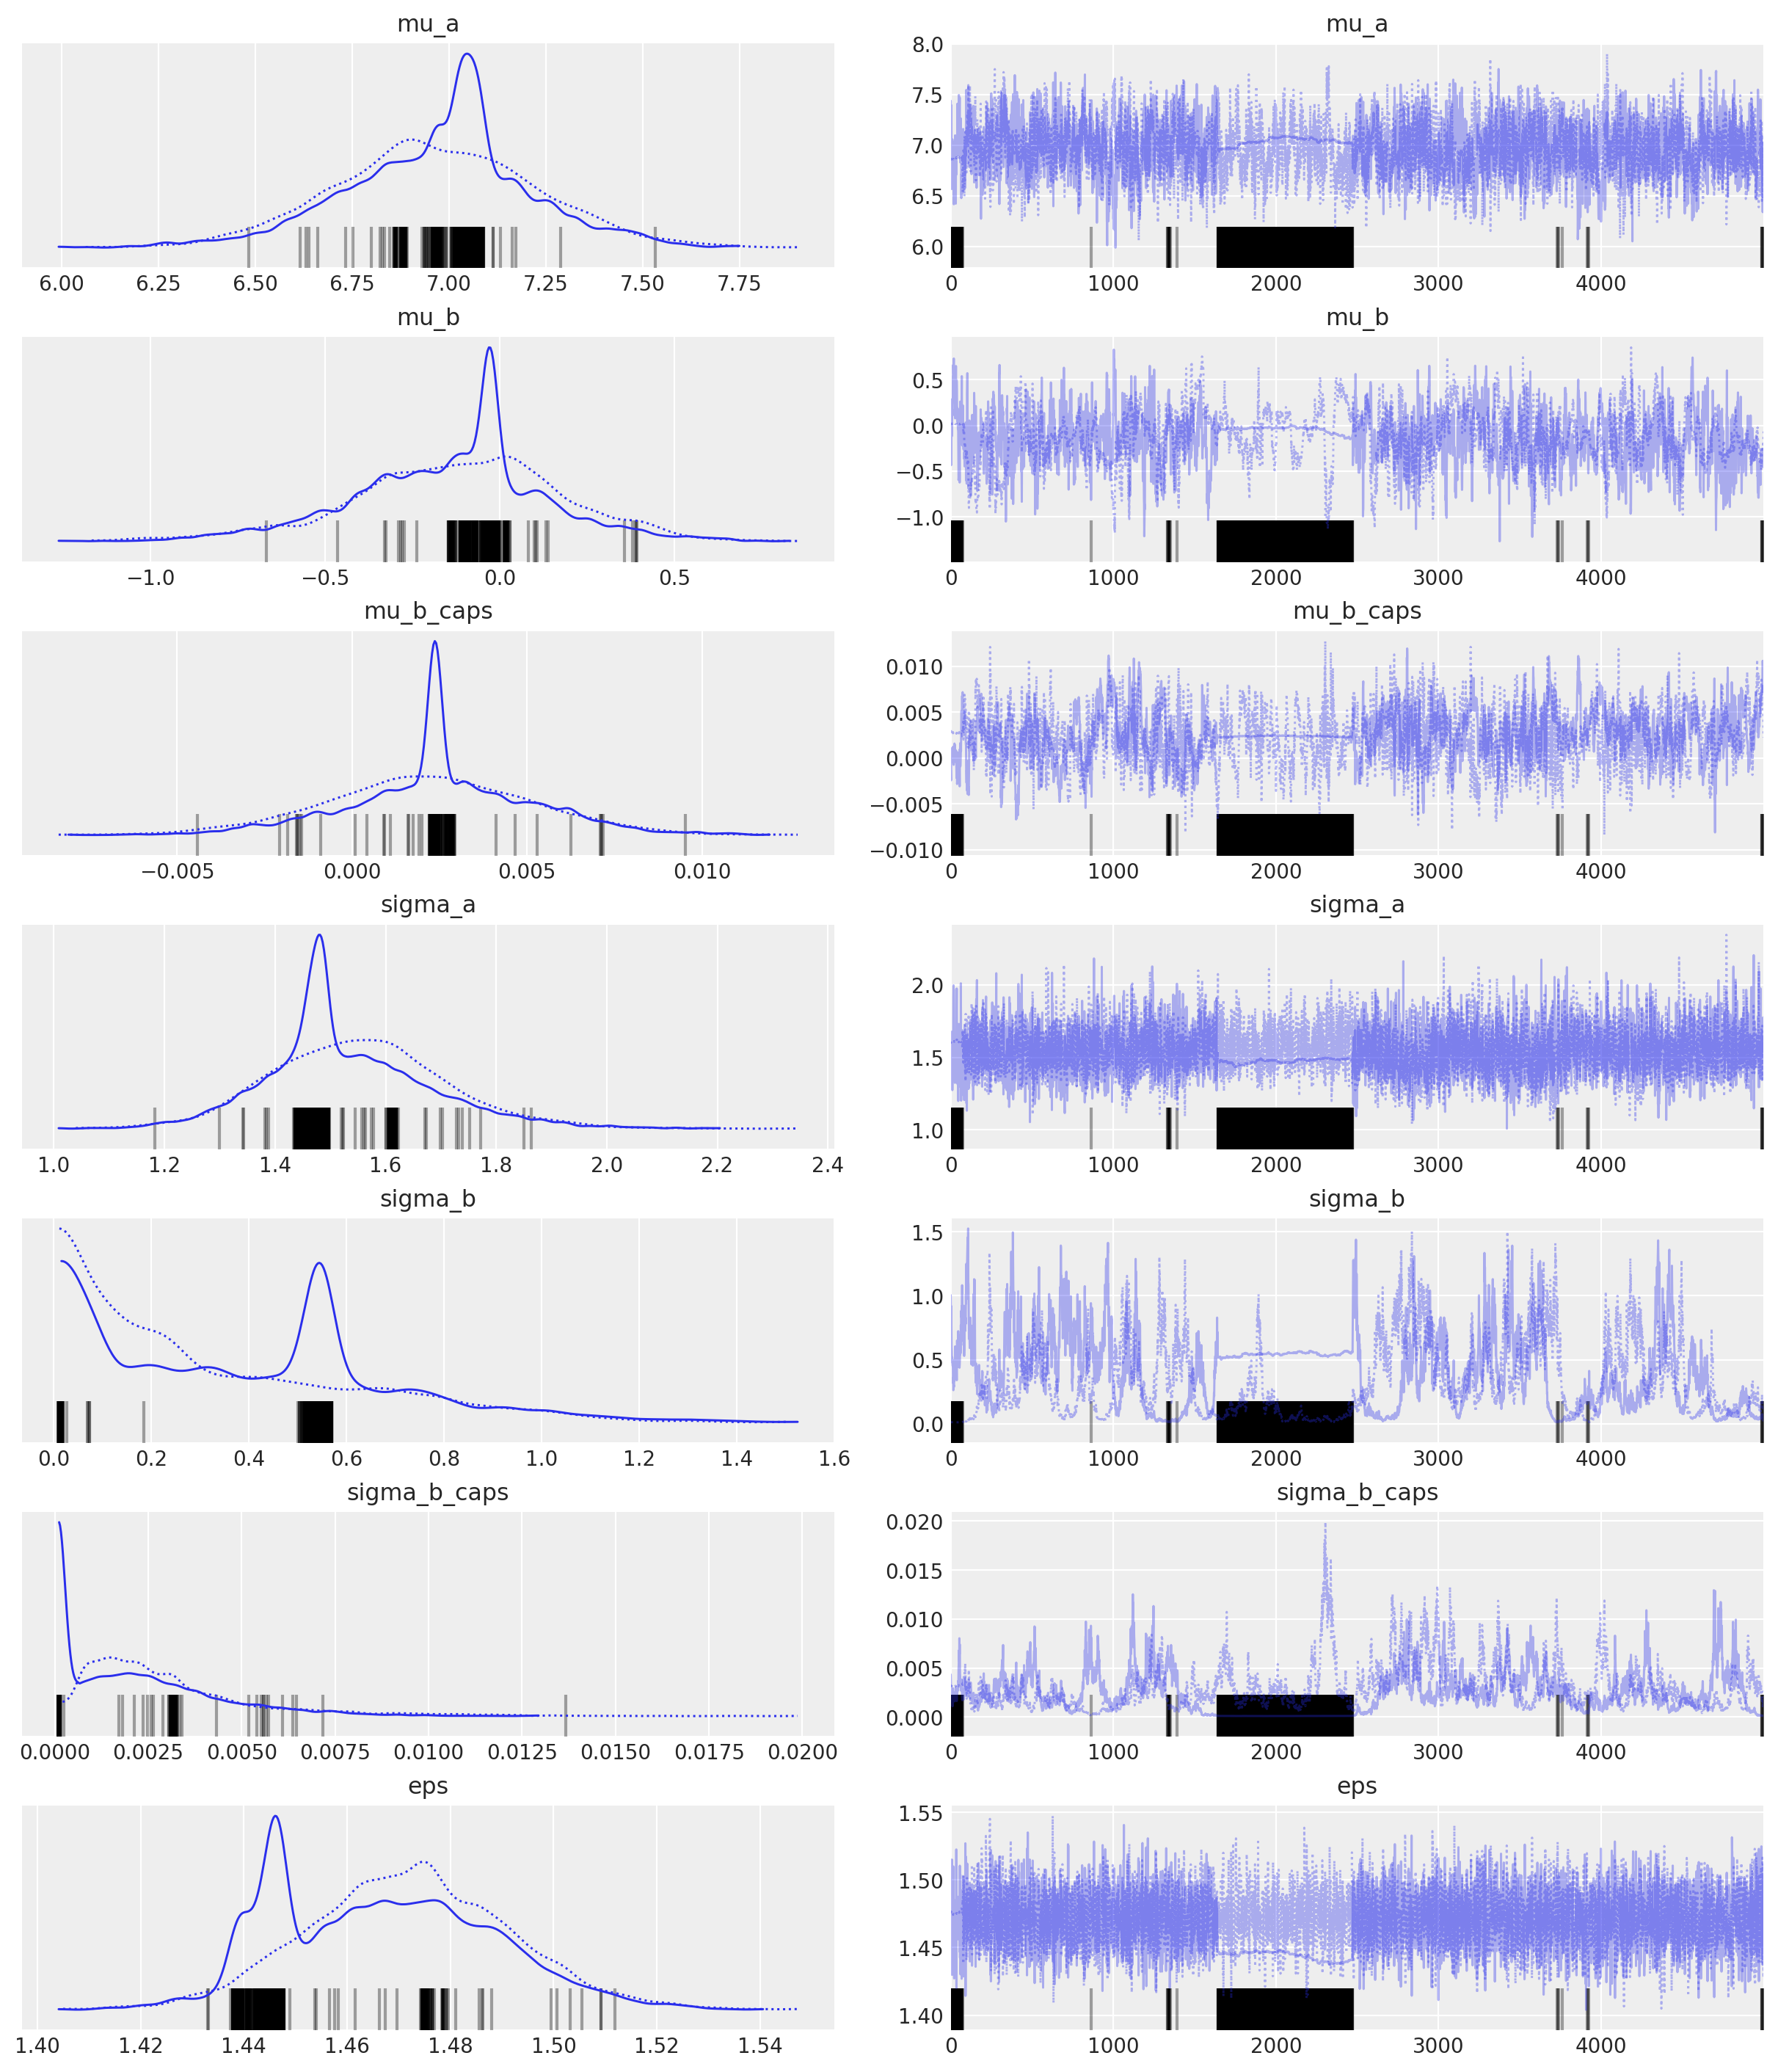

In [10]:
az.plot_trace(conf_rdm_caps_trace, var_names=["mu_a", "mu_b", "mu_b_caps", "sigma_a", "sigma_b", "sigma_b_caps", "eps"]);


In [14]:
stat_tms_reg_conf_caps=pm.summary(conf_rdm_caps_trace)
stat_tms_reg_conf_caps


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.968,0.249,6.496,7.454,0.009,0.006,735.0,1402.0,1.01
mu_b,-0.132,0.285,-0.673,0.448,0.016,0.011,307.0,552.0,1.02
mu_b_caps,0.002,0.003,-0.003,0.008,0.000,0.000,431.0,907.0,1.04
a[AD20],6.172,0.745,4.730,7.627,0.024,0.018,922.0,1632.0,1.02
a[AF12],5.510,0.537,4.577,6.639,0.025,0.017,405.0,741.0,1.01
...,...,...,...,...,...,...,...,...,...
b_caps[ZZ99],0.002,0.005,-0.007,0.010,0.000,0.000,800.0,870.0,1.05
sigma_a,1.539,0.153,1.265,1.846,0.007,0.005,466.0,1454.0,1.01
sigma_b,0.368,0.291,0.010,0.885,0.054,0.038,25.0,127.0,1.08
sigma_b_caps,0.003,0.002,0.000,0.007,0.000,0.000,16.0,11.0,1.09


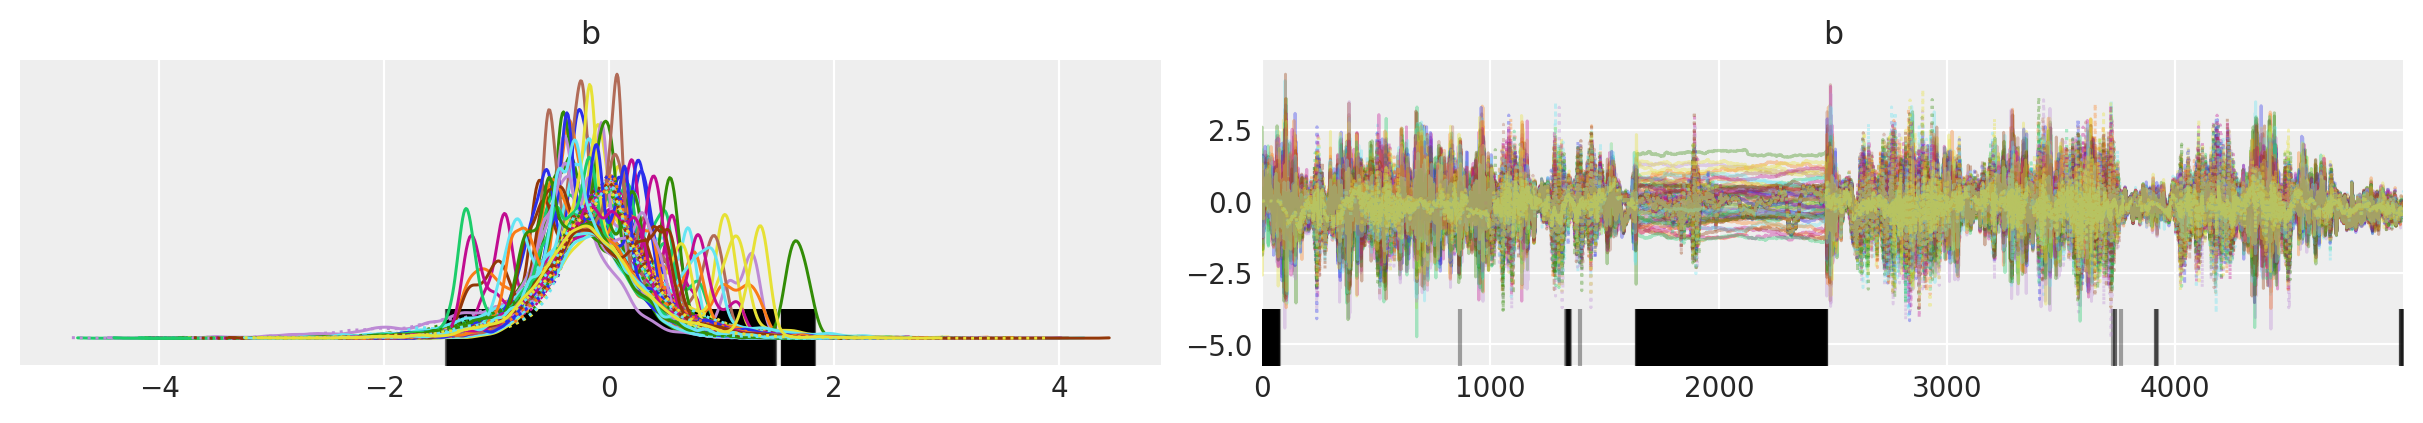

In [11]:
az.plot_trace(conf_rdm_caps_trace, var_names=["b"], coords={"participant": participant});


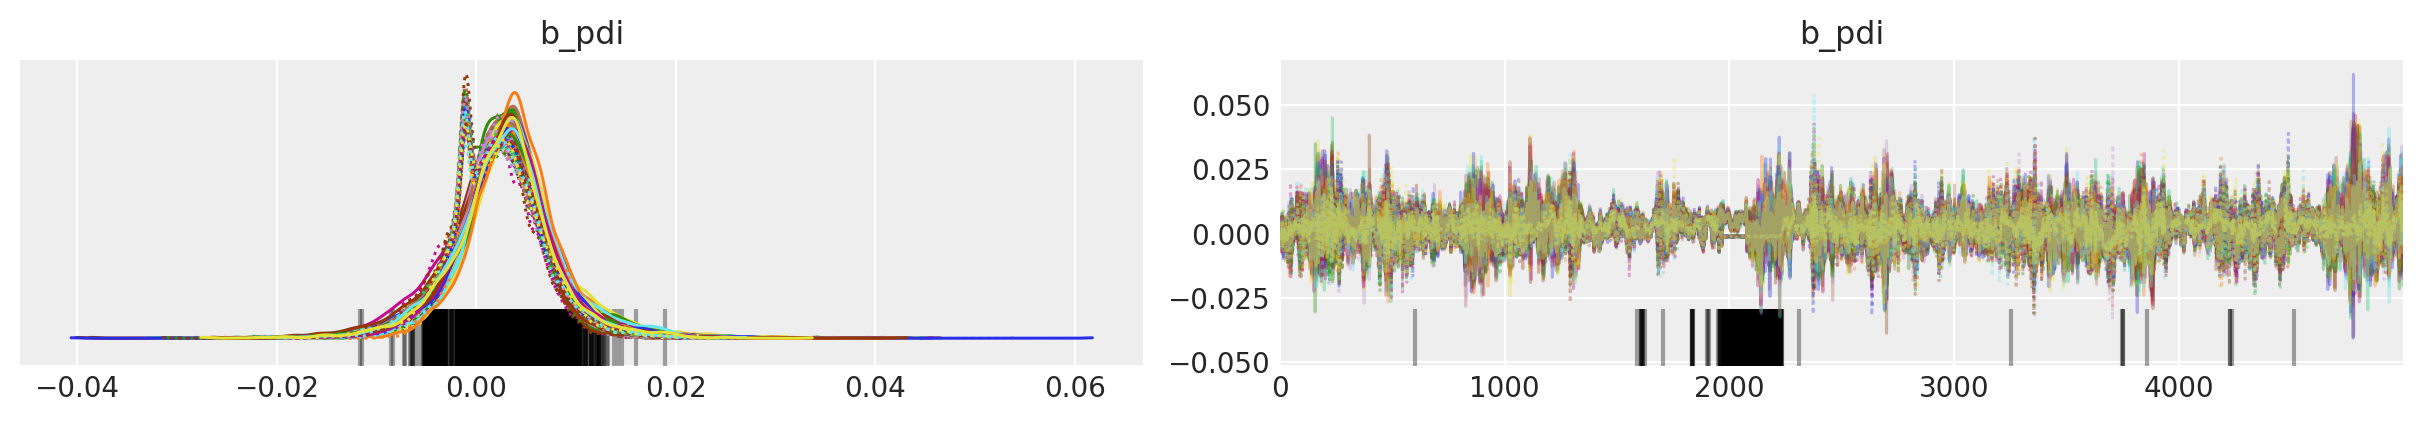

In [16]:
az.plot_trace(conf_rdm_caps_trace, var_names=["b_caps"], coords={"participant": participant});


In [17]:
b_mu_reg_conf=stat_tms_reg_conf_caps.loc['mu_b']['mean']
b_sigma_reg_conf=stat_tms_reg_conf_caps.loc['mu_b']['sd']

b_mu_reg_conf_caps=stat_tms_reg_conf_caps.loc['mu_b_caps']['mean']
b_sigma_reg_conf_caps=stat_tms_reg_conf_caps.loc['mu_b_caps']['sd']

print ("Beta TMS =/0") 
b_tms_conf=NormalDist(mu=b_mu_reg_conf, sigma=b_sigma_reg_conf).overlap(NormalDist(mu=0, sigma=b_sigma_reg_conf))
print (b_tms_conf)

print ("Beta PDI =/0") 
b_tms_conf_caps=NormalDist(mu=b_mu_reg_conf_caps, sigma=b_sigma_reg_conf_caps).overlap(NormalDist(mu=0, sigma=b_sigma_reg_conf_caps))
print (b_tms_conf_caps)

Beta TMS =/0
0.8168650606090961
Beta PDI =/0
0.7388826803635273


In [15]:
with hierarchical_model:
    ppc_reg = pm.sample_posterior_predictive(
        hierarchical_trace, var_names=["a", "b","confidence_like"]
    )

KeyError: 'confidence_like'

In [ ]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hierarchical_model))